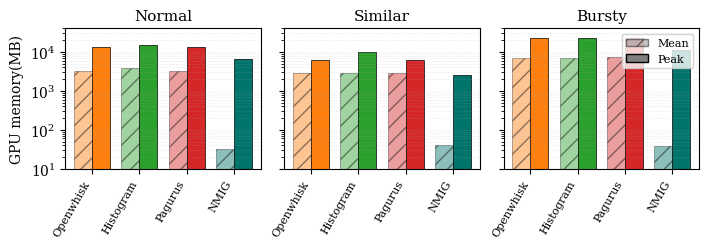

saved


In [20]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch

mpl.rcParams['font.family'] = 'DejaVu Serif'

systems = ['Openwhisk', 'Histogram', 'Pagurus', 'NMIG']
color_map = {
    "NMIG": "#00736b",
    "Openwhisk": "#ff7f0e",
    "Histogram": "#2ca02c",
    "Pagurus": "#d62728",
}

# mean and peak resident GPU memory (MB) per dataset
data = {
    'Normal': {
        'mean': {'Openwhisk': 3197.298, 'Histogram': 3805.812, 'Pagurus': 3246.038, 'NMIG': 31.849},
        'peak': {'Openwhisk': 13254, 'Histogram': 14952, 'Pagurus': 13254, 'NMIG': 6623},
    },
    'Similar': {
        'mean': {'Openwhisk': 2933.428, 'Histogram': 2801.227, 'Pagurus': 2911.707, 'NMIG': 40.995},
        'peak': {'Openwhisk': 6162, 'Histogram': 10194, 'Pagurus': 6162, 'NMIG': 2551},
    },
    'Bursty': {
        'mean': {'Openwhisk': 7030.243, 'Histogram': 6790.242, 'Pagurus': 7190.549, 'NMIG': 37.677},
        'peak': {'Openwhisk': 22910, 'Histogram': 22928, 'Pagurus': 22884, 'NMIG': 11071},
    },
}

datasets = ['Normal', 'Similar', 'Bursty']
x = np.arange(len(systems))
w = 0.38

fig, axes = plt.subplots(1, 3, figsize=(7.0, 2.4), sharey=True)

for ax, ds in zip(axes, datasets):
    means = [data[ds]['mean'][s] for s in systems]
    peaks = [data[ds]['peak'][s] for s in systems]
    colors = [color_map[s] for s in systems]

    # mean = lighter (hatched), peak = solid, both colored by system
    ax.bar(x - w/2, means, w, color=colors, alpha=0.45,
           edgecolor='black', linewidth=0.5, hatch='//')
    ax.bar(x + w/2, peaks, w, color=colors, alpha=1.0,
           edgecolor='black', linewidth=0.5)

    ax.set_yscale('log')
    ax.set_title(ds, fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(systems, fontsize=8, rotation=60, ha='right')
    ax.grid(axis='y', which='both', linestyle=':', linewidth=0.4, alpha=0.5)
    ax.set_ylim(10, 40000)

axes[0].set_ylabel('GPU memory(MB)', fontsize=10)

# legend explaining mean vs peak (color encodes system, fill encodes metric)
legend_handles = [
    Patch(facecolor='gray', alpha=0.45, hatch='//', edgecolor='black', label='Mean'),
    Patch(facecolor='gray', alpha=1.0, edgecolor='black', label='Peak'),
]
axes[2].legend(handles=legend_handles, fontsize=8, loc='upper right')

plt.tight_layout(pad=0.4)   # w_pad controls inter-panel space
plt.savefig('graphs_images/resident_mem.jpg', dpi=300, bbox_inches='tight', pad_inches=0.03)
plt.show()
print("saved")